<a href="https://colab.research.google.com/github/karye/Liu-labbar/blob/main/Lab_2_Supervised_Learning_SE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2 - Övervakad inlärning (Supervised Learning)

I denna laboration kommer du att utforska övervakad inlärning för klassificeringsproblem. Vi börjar med blomklassificering. I den andra delen av anteckningsboken tittar vi närmare på *bedrägeridetektering* (fraud detection). Vi kommer att undersöka hur man utvärderar om en maskininlärningsmodell fungerar som avsett, och vad vi kan göra om den inte gör det.

**Gör laborationen uppifrån och ned.**
<br />
**Det är inte nödvändigt att läsa längre fram än den aktuella sektionen.**

<br />
<hr />

### **Författare**
David Bergström<br />
Mattias Tiger, mattias.tiger@liu.se


### **Licens**
CC BY-NC-SA 4.0 <br />
https://creativecommons.org/licenses/by-nc-sa/4.0/

# Övervakad inlärning - Lab 2.0 - Introduktion

Först några ord om övervakad maskininlärning.
Övervakad maskininlärning är en gren av maskininlärning där man tränar eller estimerar en modell för att göra förutsägelser om utdata givet indata. Modellen tränas genom att den får flera exempel på hur indata och utdata ser ut, så kallade indata-utdata-par.
Dessa par samlas ofta i dataset, varav vissa är publika.

I denna lab är din uppgift att utvärdera en modell för övervakad maskininlärning.
Några frågor att överväga:

- Analysera resultaten, hur ser förväxlingsmatriserna (confusion matrices) ut? Är resultatet bra? Varför?
- Prova att ändra hyperparametrarna för XGBoost-modellen och se om du kan få bättre resultat (Här är en lista över alla hyperparametrar du kan ändra: https://xgboost.readthedocs.io/en/stable/parameter.html)

Vi kommer att gå igenom och diskutera labben tillsammans efter att du har gjort den på egen hand. Vi rekommenderar att ni jobbar i par.

<hr />

# Blomklassificering - Lab 2.1

## Iris-datasetet

I den här labben ska vi titta på datasetet Iris.
Datasetet består av flera mätningar på blommor i Iris-familjen.
Modellens uppgift är att använda dessa mätningar för att förutsäga blommans art. Det kommer att användas som en ersättare för till exempel ett dataset med banktransaktioner, vilket är mer relevant för bedrägeridetektering men också innehåller känslig information.

Du kan läsa mer om Iris-datasetet här om du är intresserad:

- https://en.wikipedia.org/wiki/Iris_flower_data_set

## Importera relevanta bibliotek

Eftersom detta är en notebook är texten varvad med källkod.
Låt oss importera några Python-bibliotek som vi kommer att använda:

In [ ]:
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import numpy as np
import itertools
import pandas as pd

## Ladda datasetet

Nu laddar vi datasetet.

In [ ]:
X, y = load_iris(return_X_y=True, as_frame=True)
X.rename(columns = lambda x: x.replace(' ', '_'), inplace=True)
X, y

(     sepal_length_(cm)  sepal_width_(cm)  petal_length_(cm)  petal_width_(cm)
 0                  5.1               3.5                1.4               0.2
 1                  4.9               3.0                1.4               0.2
 2                  4.7               3.2                1.3               0.2
 3                  4.6               3.1                1.5               0.2
 4                  5.0               3.6                1.4               0.2
 ..                 ...               ...                ...               ...
 145                6.7               3.0                5.2               2.3
 146                6.3               2.5                5.0               1.9
 147                6.5               3.0                5.2               2.0
 148                6.2               3.4                5.4               2.3
 149                5.9               3.0                5.1               1.8
 
 [150 rows x 4 columns],
 0      0
 1      0
 2   

Okej, det där är inte särskilt läsbart. Låt oss lägga all data i en enda Pandas-tabell.

In [ ]:
all_data = X
all_data['Species'] = y
all_data

,sepal_length_(cm),sepal_width_(cm),petal_length_(cm),petal_width_(cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


Här motsvarar varje rad en enskild växt. Kom ihåg att modellens uppgift är att förutsäga arten givet de olika mätningarna, vilket innebär att modellen ska förutsäga den sista kolumnen givet de första fyra kolumnerna.

## Uppdelning av datasetet

Inom övervakad maskininlärning arbetar vi ofta med begränsade dataset.
För att få ut det mesta av tillgänglig data delas den ofta upp i tre kategorier:

1. Träningsdata (Training dataset): Denna data används för att träna modellen.
2. Testdata (Test dataset): Denna data används för att testa den tränade modellen.
3. Valideringsdata (Validation dataset): Denna data används för slutlig validering.

Så vad är skillnaden mellan test- och valideringsdata? Den viktigaste skillnaden är att valideringsdatasetet endast bör användas **en gång**. Det är vårt sätt att mäta om maskininlärningsmodellen har lärt sig det vi vill och kan generalisera till nya, tidigare osedda indata.

Tränings- och testseten kan däremot användas flera gånger för olika modeller. Träningssetet används för att träna modellen, testsetet används för att ge en indikation på graden av generalisering under träningen. Detta används för att stoppa träningen när vi börjar överanpassa (overfit) till träningsdatan.

Men om vi tränar ett stort antal modeller och väljer den modell som presterar bäst på testsetet, riskerar vi att välja den modell som fungerar bäst på just det testsetet, snarare än att hitta den modell som generaliserar bäst. Det är då valideringsdatasetet kommer in, för att göra en slutgiltig utvärdering av modellens generalisering utanför träningssetet (och till viss del testsetet).

In [ ]:
indices = np.arange(len(all_data))

rnd = np.random.default_rng(12345)
rnd.shuffle(indices)

training = int(0.8 * len(indices))
test = int(0.1 * len(indices))
validation = int(0.1 * len(indices))

training_idx = indices[:training]
test_idx = indices[training:training+test]
validation_idx = indices[training+test:]

training_x = X.iloc[training_idx]
training_y = y.iloc[training_idx]
test_x = X.iloc[test_idx]
test_y = y.iloc[test_idx]
validation_x = X.iloc[validation_idx]
validation_y = y.iloc[validation_idx]

dtrain = xgb.DMatrix(training_x, label=training_y)
dtest = xgb.DMatrix(test_x, label=test_y)
dvalidation = xgb.DMatrix(validation_x, label=validation_y)

Okej, datan är laddad i tränings-, test- och valideringsset. Låt oss träna modellen!

In [ ]:
param = {'max_depth': 1, 'eta': 0.3, 'num_class': 3, 'subsample': 0.5}

num_round = 1

bst = xgb.train(param, dtrain, num_round)

Okej, vad händer nu? Låt oss se hur väl den kan göra förutsägelser på testsetet.

In [ ]:
test_predictions = bst.predict(dtest)

test_predictions

array([1., 1., 1., 0., 1., 2., 1., 2., 0., 2., 0., 0., 2., 0., 1.],
      dtype=float32)

Hur är dessa felaktiga förutsägelser fördelade? Är modellen lika bra för alla klasser, eller är den bättre på en klass än de andra?

**Notera:** Detta relaterar till rättvisa (fairness), där modellen kan vara incitamentstyrd att förutsäga bra på majoriteten av datan, vilket kan ske på bekostnad av prestanda på den återstående minoriteten. Om denna data på något sätt är relaterad till människor kan befintliga fördomar bevaras eller till och med förstärkas i den resulterande modellen.

Ett sätt att få en bättre överblick över resultatet är att titta på en förväxlingsmatris (confusion matrix). Här är källkoden för att rita en sådan:

In [ ]:
def plot_confusion(predictions, truth, label, classes):

  confusion = np.zeros((len(classes), len(classes)), dtype=int)

  for prediction, truth in zip(predictions, truth):
    prediction = int(prediction)
    confusion[truth, prediction] += 1

  plt.figure()
  plt.imshow(confusion, interpolation="nearest", cmap='Blues')
  title = f'Confusion matrix, for {label} data'
  plt.title(title)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes, rotation=45)
  plt.yticks(tick_marks, classes)
  normalize = False
  fmt = '.2f' if normalize else 'd'
  thresh = confusion.max() / 2.
  for i, j in itertools.product(range(confusion.shape[0]), range(confusion.shape[1])):
      plt.text(j, i, format(confusion[i, j], fmt),
              horizontalalignment="center",
              color="white" if confusion[i, j] > thresh else "black")

  plt.ylabel('True label')
  plt.xlabel('Predicted label')
  plt.tight_layout()
  plt.show()

Och här är de resulterande förväxlingsmatriserna, först för träningsdatasetet och sedan för testdatasetet.

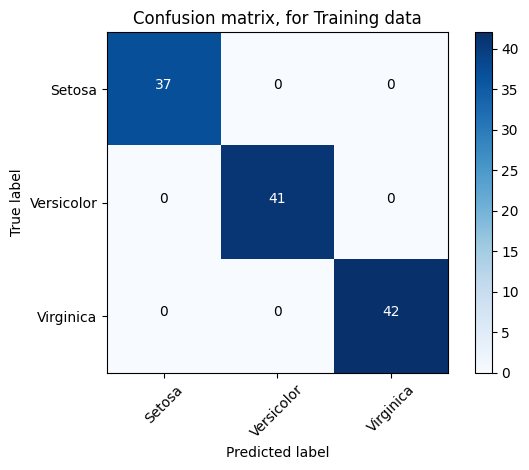

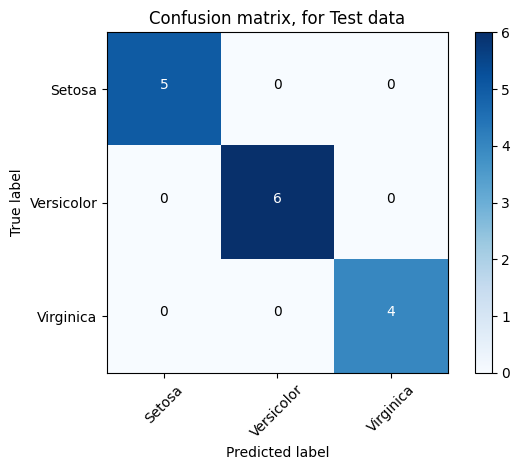

In [ ]:
training_predictions = bst.predict(dtrain)
test_predictions = bst.predict(dtest)

plot_confusion(training_predictions, training_y, 'Training', classes=['Setosa', 'Versicolor', 'Virginica'])
plot_confusion(test_predictions, test_y, 'Test', classes=['Setosa', 'Versicolor', 'Virginica'])

Den mest grundläggande formen av utvärdering är att räkna hur många gånger modellen hade rätt.

In [ ]:
print(f'Test Accuracy: {(test_predictions == test_y).mean():.2%}')

Test Accuracy: 100.00%


Ovanstående är den genomsnittliga noggrannheten (accuracy), vilket betyder att modellen fick 100% rätt svar! Ingen av de tre blomtyperna felklassificerades. Detta är sällsynt när man använder maskininlärning i praktiken.

Låt oss nu titta på ett mer komplicerat dataset.

# Bedrägeridetektering - Lab 2.2

Vi kommer att använda ett dataset om kreditkortsanvändning från en internationell tävling i bedrägeridetektering.

Läs igenom beskrivningen här (Content och Context): [https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

Låt oss nu ladda datasetet och ta en titt.

In [ ]:
fraud = pd.read_csv('https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/refs/heads/master/creditcard.csv')

In [ ]:
fraud

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


Låt oss dela upp datasetet i tränings-, test- och valideringsset.

In [ ]:
indices = np.arange(len(fraud))

rnd = np.random.default_rng(12345)
rnd.shuffle(indices)

training = int(0.8 * len(indices))
test = int(0.1 * len(indices))
validation = int(0.1 * len(indices))

training_idx = indices[:training]
test_idx = indices[training:training+test]
validation_idx = indices[training+test:]

training_x = fraud.iloc[training_idx].drop(columns=['Class'])
training_y = fraud.iloc[training_idx]['Class']
test_x = fraud.iloc[test_idx].drop(columns=['Class'])
test_y = fraud.iloc[test_idx]['Class']
validation_x = fraud.iloc[validation_idx].drop(columns=['Class'])
validation_y = fraud.iloc[validation_idx]['Class']

dtrain = xgb.DMatrix(training_x, label=training_y)
dtest = xgb.DMatrix(test_x, label=test_y)
dvalidation = xgb.DMatrix(validation_x, label=validation_y)

Hur vet vi som människor om en rad i tabellen är ett bedrägeri eller inte? (Dvs. hur representeras denna information i tabellen just nu?)

<hr />

Låt oss träna modellen!

In [ ]:
#Here are some parameters I found online. Should work, right?
param = {'objective': 'binary:logistic', 'max_depth': 1, 'eta': 0.3, 'subsample': 0.5}
num_round = 1

bst = xgb.train(param, dtrain, num_round)

Låt oss se hur väl den presterar på testsetet.

In [ ]:
test_predictions = bst.predict(dtest)
test_predictions = 1 * (test_predictions > 0.5)

print(f'Test Accuracy: {(test_predictions == test_y).mean():.2%}')

Test Accuracy: 99.35%


Bra! Vi fick mycket hög noggrannhet. Nästan perfekt!

Detta skulle säkert vara ett utmärkt system för bedrägeridetektering för min bank.

Låt oss titta på förväxlingsmatriserna, bara för att vara säkra:

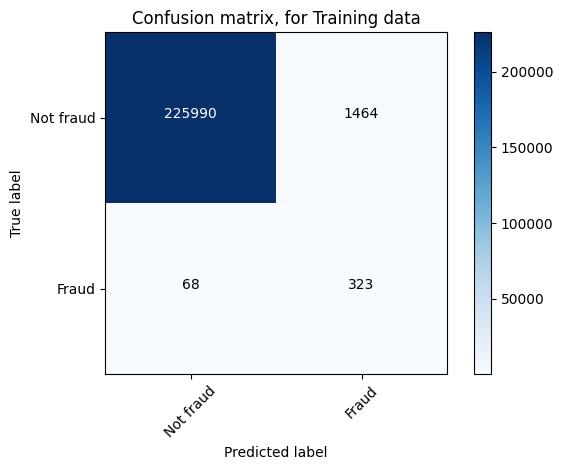

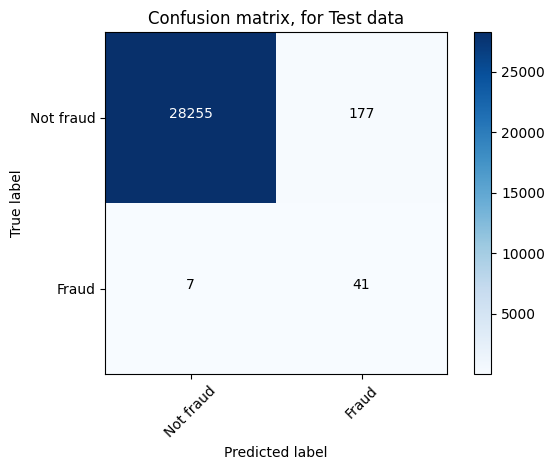

In [ ]:
training_predictions = bst.predict(dtrain)
training_predictions = 1 * (training_predictions > 0.5)

test_predictions = bst.predict(dtest)
test_predictions = 1 * (test_predictions > 0.5)


plot_confusion(training_predictions, training_y, 'Training', classes=['Not fraud', 'Fraud'])
plot_confusion(test_predictions, test_y, 'Test', classes=['Not fraud', 'Fraud'])

Testsetet används för att utvärdera hur ett AI-system kommer att bete sig när det tas i bruk och ser ny data (dvs. utvärdering av generalisering). Baserat på förväxlingsmatrisen för testdata:

1. Vad innebär detta för kunder som utsätts för bedrägeri?
  * Om du är ett offer för bedrägeri, vad är sannolikheten att bedrägeridetektorn identifierar bedrägeriet och räddar dig, baserat på förväxlingsmatrisen för testdata?

2. Vad innebär detta för kunder som inte är det?
  * Om du vill göra ett köp, vad är sannolikheten att bedrägeridetektorn felaktigt klassificerar din transaktion som bedräglig? T.ex. genom att blockera din legitima transaktion.

3. Vad tycker du om det här resultatet?
  * Skulle du vilja att din nuvarande bank införde den här bedrägeridetektorn?

---
Låt oss träna modellen igen, men med ett något bättre val av parametrar (träna längre och med en djupare modell).

In [ ]:
param = {'objective': 'binary:logistic', 'max_depth': 6, 'eta': 0.3, 'subsample': 0.5}

num_round = 10

bst = xgb.train(param, dtrain, num_round)

Låt oss se hur väl den presterar på testsetet.

In [ ]:
test_predictions = bst.predict(dtest)
test_predictions = 1 * (test_predictions > 0.5)

print(f'Test Accuracy: {(test_predictions == test_y).mean():.2%}')

Test Accuracy: 99.83%


Bra! Vi fick mycket hög noggrannhet (till och med högre än tidigare)! Låt oss ta en titt på förväxlingsmatriserna:

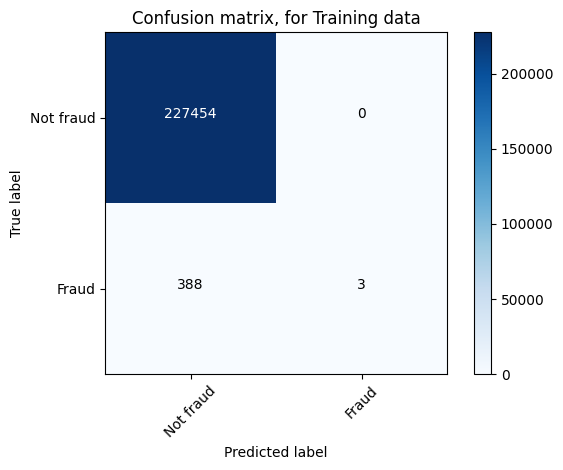

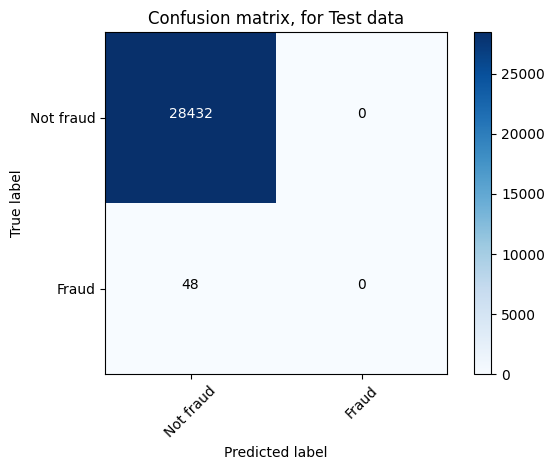

In [ ]:
training_predictions = bst.predict(dtrain)
training_predictions = 1 * (training_predictions > 0.5)

test_predictions = bst.predict(dtest)
test_predictions = 1 * (test_predictions > 0.5)


plot_confusion(training_predictions, training_y, 'Training', classes=['Not fraud', 'Fraud'])
plot_confusion(test_predictions, test_y, 'Test', classes=['Not fraud', 'Fraud'])

Testsetet används för att utvärdera hur ett AI-system kommer att bete sig när det tas i bruk och ser ny data. Baserat på förväxlingsmatrisen för testdata:

1. Vad innebär detta för kunder som utsätts för bedrägeri?
  * Om du är ett offer för bedrägeri, vad är sannolikheten att bedrägeridetektorn identifierar bedrägeriet?

2. Vad innebär detta för kunder som inte är det?
  * Vad är sannolikheten att en legitim transaktion blockeras?

3. Vad tycker du om det här resultatet?
  * Skulle du vilja att din bank använde denna modell?

# Bedrägeridetektering - Lab 2.3: Ombalansering av träningen

Som vi kunde se i förväxlingsmatrisen är nästan all data (nästan alla rader i tabellen) icke-bedrägerier. Att bara gissa att en input "inte är bedrägeri" för **all indata** ger modellen hög noggrannhet, men då löser den inte egentligen problemet med att upptäcka bedrägerier...

Även när vi tränade en djupare modell under längre tid har vi fortfarande en stor sannolikhet att felklassificera en bedräglig transaktion som icke-bedrägeri.

Hur kan vi fixa detta? Till att börja med kan vi försöka balansera om datasetet så att vi har en lika stor mängd bedrägeridata och icke-bedrägeridata.

Först, hur obalanserat är datasetet?

In [ ]:
n_fraud = (training_y == 1).sum()
print(n_fraud, 'cases of fraud.')

n_not_fraud = (training_y == 0).sum()
print(n_not_fraud, 'cases of where no fraud happend.')

print("The fraction of the data which is not fraud is", n_not_fraud/(n_not_fraud + n_fraud))



391 cases of fraud.
227454 cases of where no fraud happend.
The fraction of the data which is not fraud is 0.9982839210867037


Hur många bedrägeriprover finns det för varje icke-bedrägeriprov?

In [ ]:
scale = n_not_fraud / n_fraud
print("There are", scale, "'fraud'-samples for every 'non-fraud'-sample")

There are 581.7237851662404 'fraud'-samples for every 'non-fraud'-sample


<hr />

Vi har nu en skalfaktor som kan användas när vi tränar maskininlärningsmodellen. Den gör det möjligt för träningsproceduren att veta hur ofta den ska återanvända träningspunkter från den underrepresenterade klassen (bedrägeri i detta fall) för att göra den balanserad.

Låt oss träna med denna skalfaktor för att göra träningen balanserad.

In [ ]:
param = {'objective': 'binary:logistic', 'max_depth': 6, 'eta': 0.3, 'subsample': 0.5, 'scale_pos_weight': float(scale)} #scale_pos_weight används aldrig
# MATTIAS - DEBUG
# scale_pos_weight används aldrig även om den sätts som param.

# param = {'objective': 'binary:logistic', 'max_depth': 6, 'eta': 0.3, 'subsample': 0.5}

num_round = 10

bst = xgb.train(param, dtrain, num_round)

In [ ]:
test_predictions = bst.predict(dtest)

print('Predictions are between 0.0 and 1.0: ', test_predictions)

test_predictions = 1 * (test_predictions > 0.5)

print('Threasholding to get predictions to be either 0 or 1: ', test_predictions)
print('')
print(f'Test Accuracy: {(test_predictions == test_y).mean():.2%}')

Predictions are between 0.0 and 1.0:  [0.05251941 0.02415858 0.01988412 ... 0.02177255 0.0407142  0.02177255]
Threasholding to get predictions to be either 0 or 1:  [0 0 0 ... 0 0 0]

Test Accuracy: 99.46%


Hur ser förväxlingsmatrisen ut för modellen när vi tränar den på det här sättet?

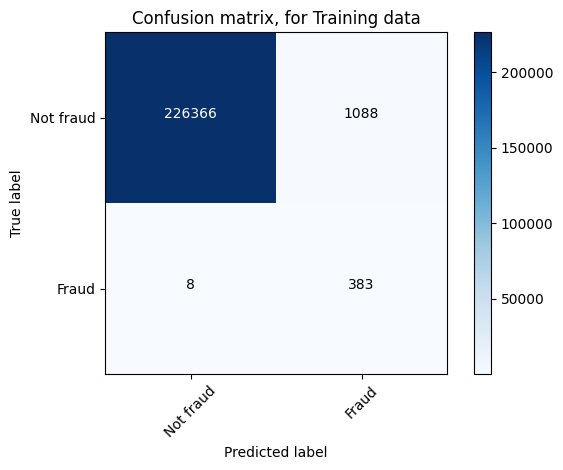

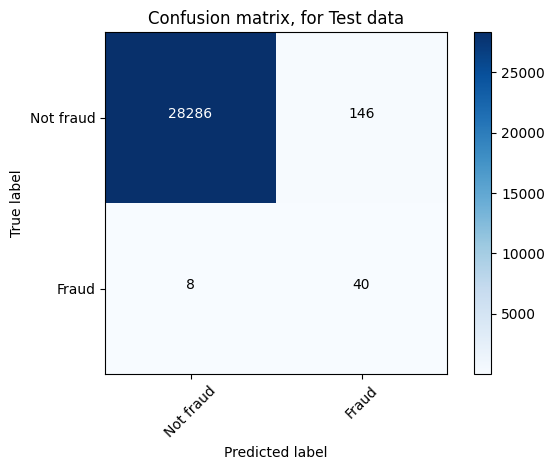

In [ ]:
training_predictions = bst.predict(dtrain)
training_predictions = 1 * (training_predictions > 0.5)
test_predictions = bst.predict(dtest)
test_predictions = 1 * (test_predictions > 0.5)

plot_confusion(training_predictions, training_y, 'Training', classes=['Not fraud', 'Fraud'])
plot_confusion(test_predictions, test_y, 'Test', classes=['Not fraud', 'Fraud'])

Okej, det här är bättre. Vi missade färre bedrägerifall.

1. Vad innebär detta för kunder som utsätts för bedrägeri?
2. Vad innebär detta för kunder som inte gör det?
3. Vad tycker du om det här resultatet?
  * Skulle du vilja att din nuvarande bank införde den här bedrägeridetektorn?

# Bedrägeridetektering - Lab 2.4: Hyperparameteroptimering (falska negativa)

Med tanke på applikationen finns det vissa fall (t.ex. kvadranter i förväxlingsmatrisen) som är mycket viktigare att ha rätt om än andra. Hur kan vi träna modellen samtidigt som vi prioriterar olika sådana fall? Låt oss ta reda på det!

Låt oss välja falska negativa (kvadranten nere till vänster) som något vi vill bli bättre på. Det betyder att vi vill minska antalet faktiska bedrägerier som vi felaktigt klassificerar som icke-bedrägerier.

Vad kan vi göra om vi bara bryr oss om falska negativa? Det vill säga, vi vill att modellen ska vara maximalt bra på just detta fall. Ett alternativ är att göra hyperparameteroptimering (tuning). Det innebär att man justerar parametrar som styr hur inlärningen sker för vår modell.

In [ ]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

Vi börjar med att definiera vad vi vill uppnå. Vi vill ha få falska negativa. Låt oss specificera att vi anser att en falsk negativ är värd 100 gånger mer än en falsk positiv (att klassificera som bedrägeri när det inte är det).

In [ ]:
def objective_fn(params):
    # eta, max_depth, subsample, colsample_bytree, colsample_bylevel, min_child_weight, alpha, lambda_, gamma, scale_pos_weight = params
    eta, max_depth, subsample, colsample_bytree, colsample_bylevel, min_child_weight, alpha, lambda_, gamma = params
    num_round=10
    model = xgb.train(
        {
            'objective': 'binary:logistic',
            'eta': eta,
            'max_depth': max_depth,
            'subsample': subsample,
            'colsample_bytree': colsample_bytree,
            'colsample_bylevel': colsample_bylevel,
            'alpha': alpha,
            'lambda': lambda_,
            'gamma': gamma,
            'scale_pos_weigth': float(scale),
            'nthread': 1,
        },
        dtrain,
        num_round)
    test_predictions = model.predict(dtest)

    confusion = np.zeros((2, 2), dtype=int)

    for prediction, truth in zip(test_predictions, test_y):
        prediction = 1 * (prediction > 0.5)
        confusion[truth, prediction] += 1

    loss = confusion[1, 0] * 10000 + confusion[0, 1] * 100

    # Return the number of false negatives
    return {'loss': loss, 'model': model, 'status': STATUS_OK}


In [ ]:
trials = Trials()

Vi kommer nu att hitta de bästa inlärningsparametrarna (hyperparametrar) som minimerar förlusten (loss), och vi gör detta enligt en sannolikhetsfördelning över värdena för de olika parametrarna.

Hur vi gör det är via Bayesiansk optimering, vilket är en kombination av optimering och maskininlärning. Det är mycket effektivt och kräver endast ett fåtal försök (vi använder 100 här) för att hitta en riktigt bra konfiguration.

In [ ]:
best = fmin(objective_fn,
            space=[hp.loguniform('eta', np.e**-7, 1),
                1 + hp.randint('max_depth', 9),
                hp.uniform('subsample', 0.2, 1),
                hp.uniform('colsample_bytree', 0.2, 1),
                hp.uniform('colsample_bylevel', 0.2, 1),
                hp.loguniform('min_child_weight', np.e**-16, np.e**5),
                hp.choice('alpha', [0, hp.loguniform('a', np.e**-16, np.e**2)]),
                hp.choice('lambda', [0, hp.loguniform('l', np.e**-16, np.e**2)]),
                hp.choice('gamma', [0, hp.loguniform('g', np.e**-16, np.e**2)]),
                #  hp.uniform('scale_pos_weight', 0, 1),
                ],
            algo=tpe.suggest,
            max_evals=100,
            trials=trials,
            rstate=np.random.seed(12345))

  0%|          | 0/100 [00:00<?, ?trial/s, best loss=?]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:28:32] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "scale_pos_weigth" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



  1%|          | 1/100 [00:00<00:47,  2.06trial/s, best loss: 480000.0]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:28:33] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "scale_pos_weigth" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



  5%|▌         | 5/100 [00:01<00:25,  3.65trial/s, best loss: 144400.0]

...

 94%|█████████▍| 94/100 [00:34<00:02,  2.85trial/s, best loss: 82200.0]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:29:07] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "scale_pos_weigth" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 97%|█████████▋| 97/100 [00:35<00:00,  3.09trial/s, best loss: 82200.0]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:29:08] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "scale_pos_weigth" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



100%|██████████| 100/100 [00:36<00:00,  2.77trial/s, best loss: 82200.0]


Nu väljer vi den bästa modellen som vi hittade (dvs. den med de bästa inlärningsparametrarna).

In [ ]:
i = np.argmin(trials.losses())
best = trials.results[i]

best_model = best['model']

# Extract predictions and calculate the test accuracy
training_predictions = best_model.predict(dtrain)
training_predictions = 1 * (training_predictions > 0.5)
test_predictions = best_model.predict(dtest)
test_predictions = 1 * (test_predictions > 0.5)

print(f'Test Accuracy: {(test_predictions == test_y).mean():.2%}')

Test Accuracy: 99.89%


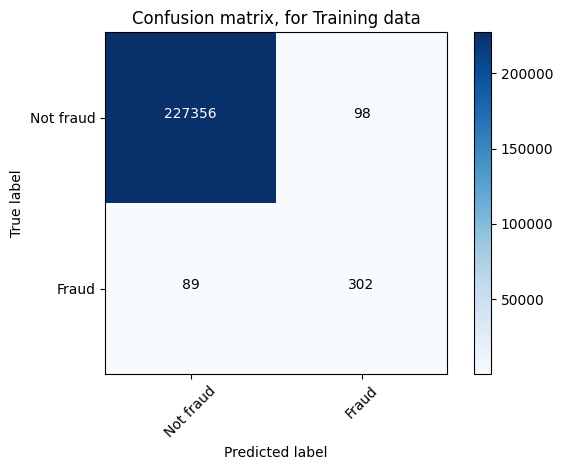

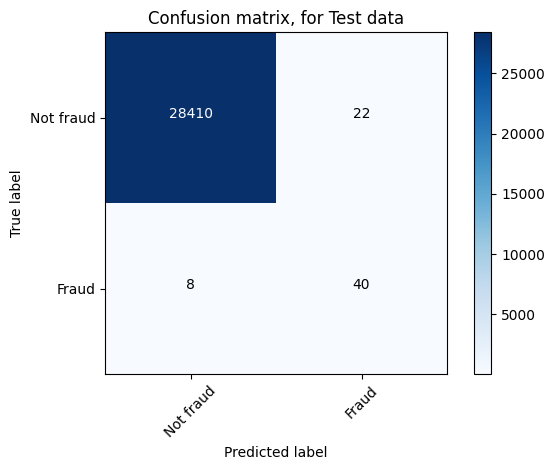

In [ ]:
plot_confusion(training_predictions, training_y, 'Training', classes=['Not fraud', 'Fraud'])
plot_confusion(test_predictions, test_y, 'Test', classes=['Not fraud', 'Fraud'])

Hur mycket bättre blev det?

1. Vad innebär detta för kunder som utsätts för bedrägeri?
2. Vad innebär detta för kunder som inte gör det?
3. Vad tycker du om det här resultatet?
4. Vilka slutsatser kan du dra från den här labben angående förhållandet mellan noggrannhet (accuracy) och affärsvärde?